# TS5 - Estimacion Espectral 2, Ventanas

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 

Funciones auxiliares:

In [42]:

def plot_psd_señal(xx, fs, N, title="Densidad Espectral de Potencia", type="scatter", xlabel="freq"):
    xx_fft = np.fft.fft(xx)
    freqs = np.fft.fftfreq(N, d=1/fs)

    psd = 2 * (1/(fs*N)) * np.abs(xx_fft)**2

    mask = freqs >= 0
    freqs = freqs[mask]
    psd = psd[mask]

    if xlabel =="k":
        freqs = np.arange(len(psd))
        xlb = "k"
    else:
        xlb = "Frecuencia (Hz)"

    figure, axs = plt.subplots(2, 1, figsize=(12, 8))
    if type == "scatter":
        axs[0].scatter(freqs, psd)
    else:
        axs[0].plot(freqs, psd)
    axs[0].set_xlabel(xlb)
    axs[0].set_ylabel('Modulo de X(k) [W]')
    axs[0].grid(True)
    axs[0].set_title(title)

    if type == "scatter":
        axs[1].scatter(freqs, 10*np.log10(psd))
    else:
        axs[1].plot(freqs, 10*np.log10(psd))
    axs[1].set_xlabel(xlb)
    axs[1].set_ylabel('Modulo de X[k] [dB]')
    axs[1].grid(True)
    axs[1].set_title("Señal en dB")

    figure.tight_layout()
    plt.show()

    return psd, freqs

Vamos a generar una señal senoidal donde la frecuencia este compuesta sea una variable aleatoria.
$$
x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)
$$

$$
\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}
$$

$$
\Omega_0 = \frac{\pi}{2}
$$

Con las variables aleatorias:

$$
f_r \sim \mathcal{U}(-2,\,2)
$$

$$
n_a \sim \mathcal{N}(0,\,\sigma^2)
$$


Tendremos un vector $N$ de 1000 muestras y una cantidad $R$ de 200 realizaciones.

Primero probaremos un SNR de señal de 10 dB.

Si tenemos una potencia de señal normalizada de 1W (0 dB) tenemos que tener -10 dB de potencia de ruido.

In [43]:
N = 1000
fs = 1000
realizaciones = 200

fr = np.random.uniform(-2, 2, realizaciones)

def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

pot_ruido_db = -10
na, _ = pds_awgn(N, fs=1000, potencia_W=10**(pot_ruido_db/10))

Ahora formamos una matriz de RxN que contenga los valores de las 1000 muestras de cada realizacion.

In [44]:
Omega0 = np.pi / 2
Omega1 = Omega0 + fr * (2*np.pi/N)
Omega1 = Omega1.reshape((realizaciones,1))

ang =  Omega1 * np.arange(N).reshape((1,N))
x = np.sqrt(2) * np.sin(ang) + na

Podemos ver el tamaño de la matriz resultante para verificar que las multiplicaciones son correctas (por lo menos en las dimensiones):

In [45]:
print(f"Shape de x: {x.shape}")

Shape de x: (200, 1000)


Ahora calculamos la FFT de la matriz, con el $axis=1$ para que se haga en el eje de muestras.

Despues calculamos el modulo (normalizado) de la matriz.

In [46]:
x_fft = np.fft.fft(x, axis=1)
x_fft_abs = np.abs(x_fft)/N

Podemos graficar algunas realizaciones para ver como es la distribucion de potencia:

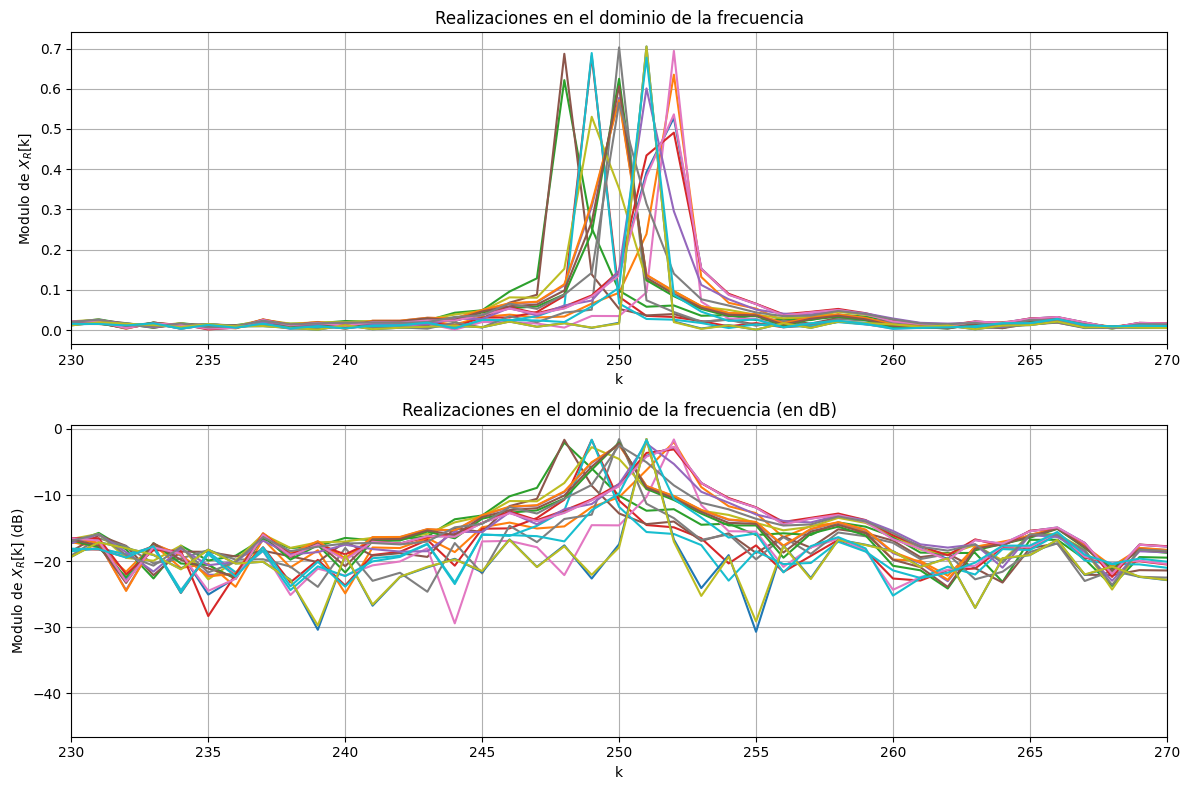

In [47]:
figure, axs = plt.subplots(2, 1, figsize=(12, 8))
for i in range(0, 20):
    axs[0].plot(x_fft_abs[i,:])
axs[0].grid(True)
axs[0].set_title("Realizaciones en el dominio de la frecuencia")
axs[0].set_xlabel("k")
axs[0].set_ylabel("Modulo de $X_R$[k]")
axs[0].set_xlim(N//4-20, N//4+20)

for i in range(0, 20):
    axs[1].plot(10*np.log10(x_fft_abs[i,:]))
axs[1].grid(True)
axs[1].set_title("Realizaciones en el dominio de la frecuencia (en dB)")
axs[1].set_xlabel("k")
axs[1].set_ylabel("Modulo de $X_R$[k] (dB)")
axs[1].set_xlim(N//4-20, N//4+20)
figure.tight_layout()
plt.show()

Definimos el primer estimador, un estimador de energia:

$$
\hat{a}_1^{\,i} = \left| X_w^{\,i}(\Omega_0) \right| = \left| \mathcal{F}\{ x(n)\cdot w_i(n) \} \right|
$$

Siendo $w_i(n)$ la ventana, de la que todavia no hablamos nada. Todavia estamos usando la ventana implicita, que segun vimos en la TS4, genera el kernel de Dirichlet en frecuencia.

Este estimador intenta estimar, valga la redundancia, la energia de la señal obteniendo el valor del bin de $\Omega_0$. No es un buen estimador porque como ya vimos y graficamos, la potencia de la señal está en centrada en distintas frecuencias segun la realizacion gracias a la variable aleatoria que conforma $\Omega_1$ 

Vamos a graficar el histograma de 3 estimadores, uno que toma la energia de $\Omega_0$ como ya dijimos, pero despues otros dos que toman la energia en $\Omega_0 - 1$ y $\Omega_0 + 1$.

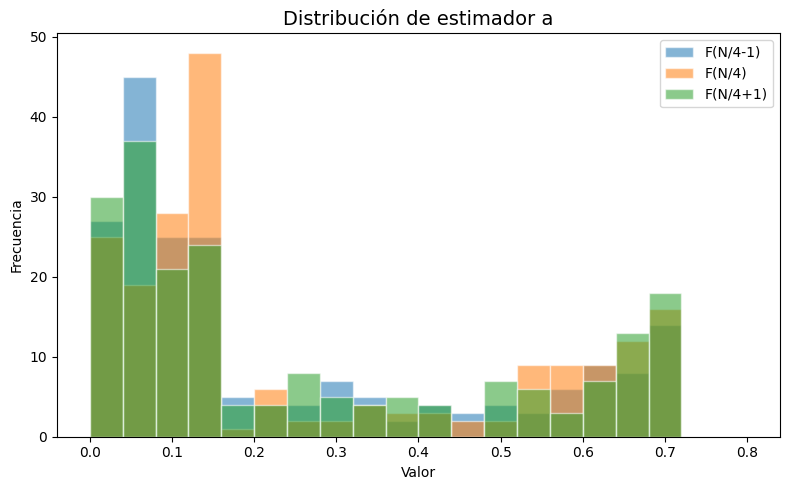

Media del estimador: 0.272
Varianza del estimador: 0.059
Sesgo del estimador: -0.435


In [50]:
estimador_a_1 = (x_fft_abs[:,int(N/4-1)])
estimador_a = (x_fft_abs[:,int(N/4)])
estimador_a1 = (x_fft_abs[:,int(N/4+1)])
plt.figure(figsize=(8, 5))
plt.hist(estimador_a_1, label="F(N/4-1)", bins=20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.hist(estimador_a, label="F(N/4)",bins = 20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.hist(estimador_a1, label="F(N/4+1)", bins=20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()

sesgo_a = np.mean(estimador_a) - np.sqrt(2)/2

print(f"Media del estimador: {np.mean(estimador_a):.3f}")
print(f"Varianza del estimador: {np.var(estimador_a):.3f}")
print(f"Sesgo del estimador: {sesgo_a:.3f}")

Vemos que la distribucion de los 3 estimadores son similares. Volvemos a tomar el estimador que mencionamos al principio y le vamos a corregir el sesgo

<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
C:\Users\tomas\AppData\Local\Temp\ipykernel_5172\381561617.py:4: SyntaxWarning: invalid escape sequence '\O'
  plt.hist(estimador_a_corregido, label="$|X(\Omega_0)|$ corregido", bins=20, edgecolor='white', alpha=0.55)


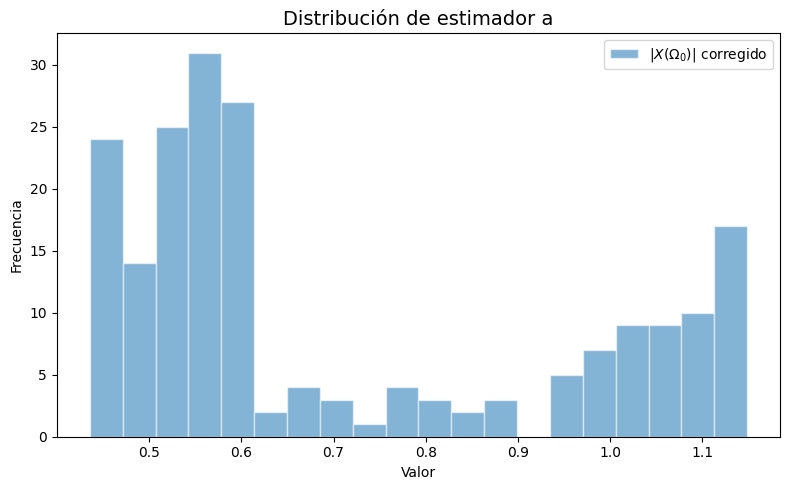

In [52]:
estimador_a_corregido = estimador_a - sesgo_a

plt.figure(figsize=(8, 5))
plt.hist(estimador_a_corregido, label="$|X(\Omega_0)|$ corregido", bins=20, edgecolor='white', alpha=0.55)
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()


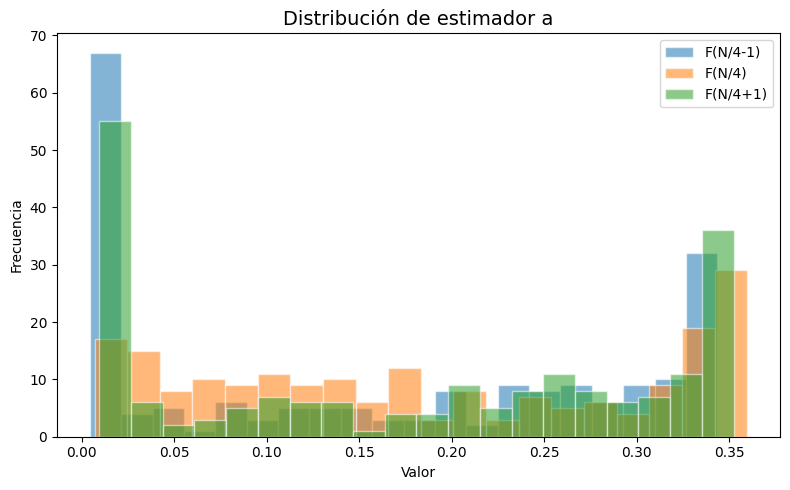

Media del estimador: 0.18812668175250408
Varianza del estimador: 0.01446398904578259


In [49]:
flattop = scipy.signal.windows.hann(N)
x_flattop = x * flattop

x_fft_ft = np.fft.fft(x_flattop, axis=1)
x_fft_ft_abs = np.abs(x_fft_ft)/N

estimador_a_1 = (x_fft_ft_abs[:,int(N/4-1)])
estimador_a = (x_fft_ft_abs[:,int(N/4)])
estimador_a1 = (x_fft_ft_abs[:,int(N/4+1)])
plt.figure(figsize=(8, 5))
plt.hist(estimador_a_1, label="F(N/4-1)", bins=20, edgecolor='white', alpha=0.55)
plt.hist(estimador_a, label="F(N/4)",bins = 20, edgecolor='white', alpha=0.55)
plt.hist(estimador_a1, label="F(N/4+1)", bins=20, edgecolor='white', alpha=0.55)
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()


print(f"Media del estimador: {np.mean(estimador_a)}")
print(f"Varianza del estimador: {np.var(estimador_a)}")